In [1]:
# Install
%pip install torch
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from MLP import FashionMLP
from Part1 import train

In [3]:
# Set seed
seed = 42
torch.manual_seed(seed)
# Set device to GPU if available, otherwise CPU
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
print(f"Using device: {device}")

Using device: cpu


In [4]:
# Préparation de données

# Normalement on aurait calculé la moyenne et l'écart-type de Fashion-MNIST, mais ici ils sont donnés
mean = 0.2860
std = 0.3530

# Voici la transformé pour expérience 2

transform_exp2 = transforms.Compose([
    transforms.Lambda(lambda img: torch.from_numpy(np.array(img)).float())
])

# Voici la transformé pour le reste des expériences
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

# Transformée non normalisée (expérience 1)
transform_no_normalization = transforms.Compose([
    transforms.ToTensor()
])


def get_loaders(batch_size, transform):
    os.makedirs("./data", exist_ok=True)

    # Download and load training data
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, transform=transform, download=True
    )

    # Download and load test data
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, transform=transform, download=True
    )
    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset, batch_size=batch_size, shuffle=True
    )
    test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset, batch_size=batch_size, shuffle=False
    )
    return train_loader, test_loader


In [5]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

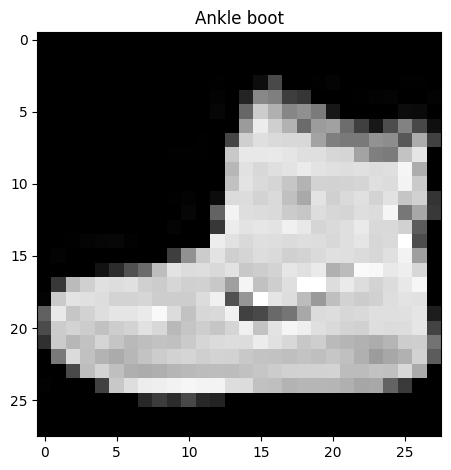

[[[-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01
   -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01]
  [-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01
   -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01]
  [-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.10198

In [6]:
# Voyons un peu de quoi a l'air le jeu de données
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
)

np.set_printoptions(linewidth=350)

image_tensor, label_idx = train_dataset[0]
image_numpy = image_tensor.squeeze().numpy()
fig = plt.figure()
plt.imshow(image_numpy, cmap='gray')
plt.title(class_names[label_idx])
plt.tight_layout()
plt.show()
print(image_tensor.numpy())

In [7]:
# Voici un fonction pour visualiser quelques exemples
def visualize_samples(dataset, num_samples=10):
    """
    Plots a grid of random images from the dataset with their labels.
    """
    fig = plt.figure(figsize=(12, 5))

    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        image_tensor, label_idx = dataset[idx]
        image_numpy = image_tensor.squeeze().numpy()
        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image_numpy, cmap='gray')
        ax.set_title(class_names[label_idx])
    plt.tight_layout()
    plt.show()

Total number of training images: 60000
Displaying random samples...


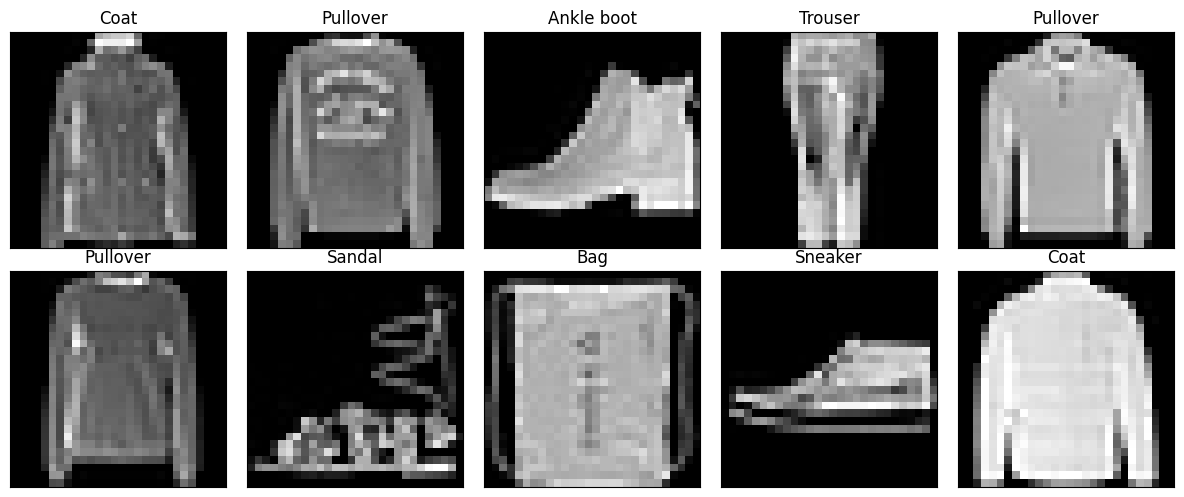

In [8]:
print(f"Total number of training images: {len(train_dataset)}")
print("Displaying random samples...")

visualize_samples(train_dataset, num_samples=10)

In [9]:
# Hyperparamètres d'entraînement
BATCH_SIZE = 64
LEARNING_RATE = 0.05
EPOCHS = 30

In [10]:
# Hyperparamètres du modèle
INPUT_SIZE = 28 * 28
H1_SIZE = 64
H2_SIZE = 64
OUTPUT_SIZE = 10

ACTIVATION1 = nn.Sigmoid()
ACTIVATION2 = nn.Sigmoid()

In [11]:
model = FashionMLP(input_size=INPUT_SIZE,
                   h1_size=H1_SIZE,
                   h2_size=H2_SIZE,
                   output_size=OUTPUT_SIZE,
                   activation1=ACTIVATION1,
                   activation2=ACTIVATION2
                   ).to(device)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (activation1): Sigmoid()
  (activation2): Sigmoid()
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
)


In [12]:
for param in model.parameters():
    print(type(param), param.size())

<class 'torch.nn.parameter.Parameter'> torch.Size([64, 784])
<class 'torch.nn.parameter.Parameter'> torch.Size([64])
<class 'torch.nn.parameter.Parameter'> torch.Size([64, 64])
<class 'torch.nn.parameter.Parameter'> torch.Size([64])
<class 'torch.nn.parameter.Parameter'> torch.Size([10, 64])
<class 'torch.nn.parameter.Parameter'> torch.Size([10])


In [13]:
def mse_los(outputs, labels):
    targets_one_hot = F.one_hot(labels, num_classes=outputs.size(1)).float()
    probs = F.softmax(outputs, dim=1)
    return F.mse_loss(probs, targets_one_hot)


def hinge_loss_simple(outputs, labels, margin=1.0):
    correct_scores = outputs.gather(1, labels.view(-1, 1))
    margins = outputs - correct_scores + margin
    loss = torch.max(torch.zeros_like(margins), margins)
    loss.scatter_(1, labels.view(-1, 1), 0)
    return loss.sum(1).mean()

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),
                      lr=LEARNING_RATE)  # Nous utilisons SGD tel que vu en classe. Ne changer pas l'optimizer
train_loader, test_loader = get_loaders(BATCH_SIZE,
                                        transform)  # added second arg that was forgotten in initial given code

In [15]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model=model,
    epochs=EPOCHS,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device
)

Starting training...
Epoch [1/30] | Train Loss: 1.6181 | Test Loss: 1.1171 | Train Accuracy: 44.61 | Test Accuracy: 59.54%
Epoch [2/30] | Train Loss: 0.9149 | Test Loss: 0.7714 | Train Accuracy: 68.05 | Test Accuracy: 71.38%
Epoch [3/30] | Train Loss: 0.6758 | Test Loss: 0.6315 | Train Accuracy: 75.41 | Test Accuracy: 76.75%
Epoch [4/30] | Train Loss: 0.5708 | Test Loss: 0.5554 | Train Accuracy: 79.17 | Test Accuracy: 79.82%
Epoch [5/30] | Train Loss: 0.5068 | Test Loss: 0.5100 | Train Accuracy: 82.27 | Test Accuracy: 81.61%
Epoch [6/30] | Train Loss: 0.4656 | Test Loss: 0.4812 | Train Accuracy: 83.71 | Test Accuracy: 82.85%
Epoch [7/30] | Train Loss: 0.4366 | Test Loss: 0.4613 | Train Accuracy: 84.67 | Test Accuracy: 83.55%
Epoch [8/30] | Train Loss: 0.4155 | Test Loss: 0.4443 | Train Accuracy: 85.33 | Test Accuracy: 84.34%
Epoch [9/30] | Train Loss: 0.3984 | Test Loss: 0.4295 | Train Accuracy: 86.01 | Test Accuracy: 84.65%
Epoch [10/30] | Train Loss: 0.3833 | Test Loss: 0.4162 | Trai

In [16]:
# Visualisation
def visualize(experiment, experiment_name, epochs):
    plt.figure(figsize=(12, 5))

    # Plot training loss
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), experiment[0], marker='o', color='orange', label=f'{experiment_name} Train Loss')
    plt.plot(range(1, epochs + 1), experiment[1], marker='x', ls="--", color='orange',
             label=f'{experiment_name} Test Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Plot test accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), experiment[2], marker='o', color='orange', label=f'{experiment_name} train Accuracy')
    plt.plot(range(1, epochs + 1), experiment[3], marker='x', ls="--", color='orange',
             label=f'{experiment_name} Test Accuracy')
    plt.title('Test Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'exp_{experiment_name}.png')
    plt.show()

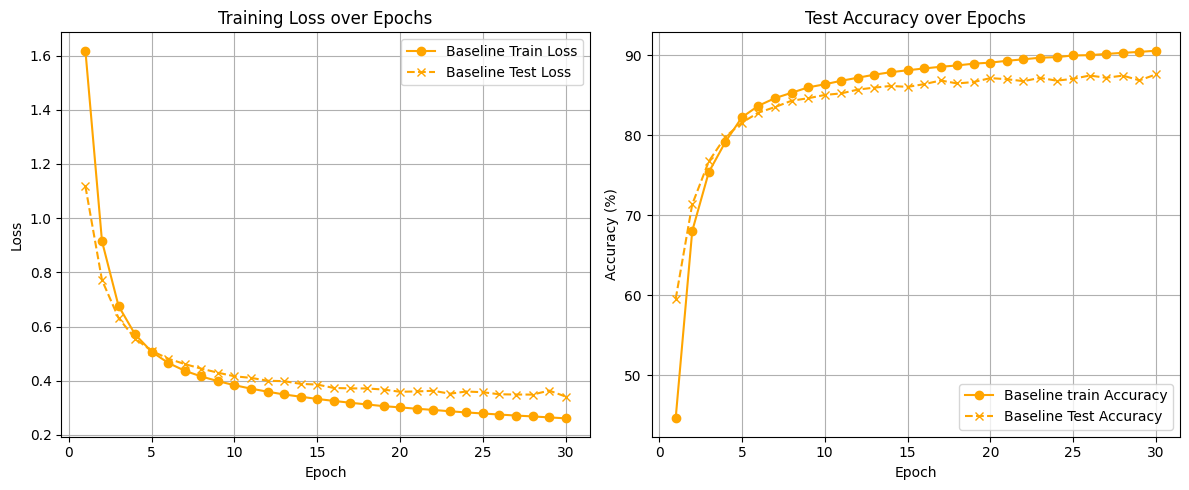

Baseline final test accuracy: 87.63
Baseline best test accuracy: 87.63


In [17]:
baseline_experiment = (train_losses, test_losses, train_accuracies, test_accuracies)
visualize(baseline_experiment, "Baseline", EPOCHS)

print("Baseline final test accuracy:", test_accuracies[-1])
print("Baseline best test accuracy:", max(test_accuracies))

In [18]:
# Une fonction sympa pour voir les exemples mal classifiés
def get_model_failures(model, loader, device):
    """
    Runs the model on the loader and returns a list of (image, true_label, predicted_label)
    for every instance where the model was wrong.
    """
    model.eval()
    failures = []

    print("Analyzing test set for failures...")
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            mask = predicted != labels
            wrong_imgs = images[mask].cpu()
            wrong_labels = labels[mask].cpu()
            wrong_preds = predicted[mask].cpu()

            for i in range(len(wrong_imgs)):
                failures.append((wrong_imgs[i], wrong_labels[i].item(), wrong_preds[i].item()))

    print(f"Analysis complete. Model failed on {len(failures)} images.")
    return failures


def visualize_failures(failures, class_names, num_samples=10):
    """
    Specialized visualization for failures to show what the model
    thought the image was versus reality.
    """
    if not failures:
        print("No failures to display!")
        return

    num_samples = min(num_samples, len(failures))
    fig = plt.figure(figsize=(15, 7))

    indices = np.random.choice(len(failures), num_samples, replace=False)

    for i, idx in enumerate(indices):
        image_tensor, true_label, pred_label = failures[idx]

        image_numpy = image_tensor.squeeze().numpy()

        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image_numpy, cmap='gray')

        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
        ax.set_title(title, fontsize=10)

    plt.tight_layout()
    plt.suptitle("Model Misclassifications", fontsize=16, y=1.05)
    plt.show()

In [19]:
failed_data = get_model_failures(model, test_loader, device)

Analyzing test set for failures...
Analysis complete. Model failed on 1237 images.


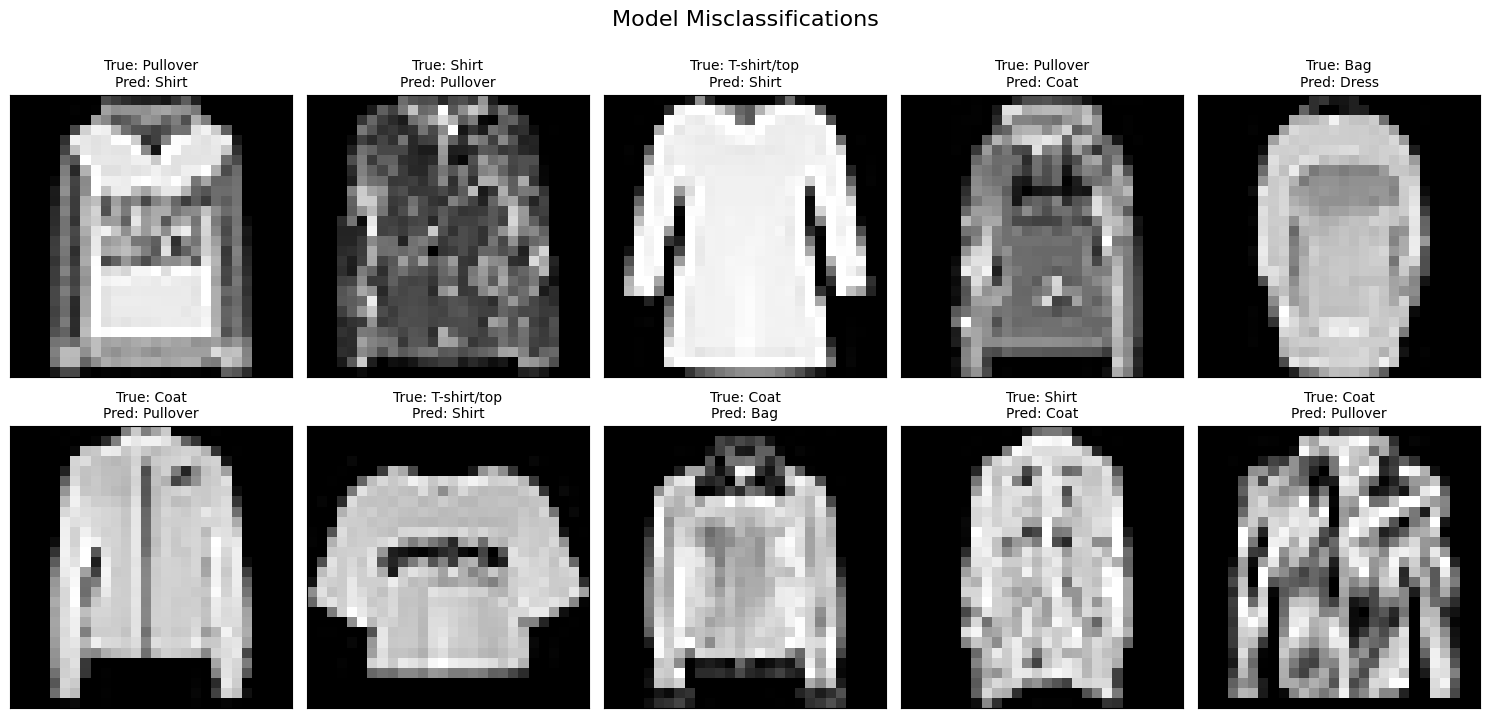

In [20]:
visualize_failures(failed_data, class_names, num_samples=10)

In [21]:
# Résumé
results_summary = []

results_summary.append({
    "Experiment": "Baseline",
    "Final Train Loss": baseline_experiment[0][-1],
    "Final Test Loss": baseline_experiment[1][-1],
    "Final Train Accuracy": baseline_experiment[2][-1],
    "Final Test Accuracy": baseline_experiment[3][-1],
    "Best Test Accuracy": max(baseline_experiment[3])
})

## Experience 1

In [22]:
model_exp1 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp1 = nn.CrossEntropyLoss()
optimizer_exp1 = optim.SGD(model_exp1.parameters(), lr=0.05)

train_loader_exp1, test_loader_exp1 = get_loaders(64, transform_no_normalization)

exp1 = train(
    model=model_exp1,
    epochs=20,
    optimizer=optimizer_exp1,
    criterion=criterion_exp1,
    train_loader=train_loader_exp1,
    test_loader=test_loader_exp1,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 2.0974 | Test Loss: 1.6221 | Train Accuracy: 24.82 | Test Accuracy: 48.66%
Epoch [2/20] | Train Loss: 1.2878 | Test Loss: 1.0803 | Train Accuracy: 55.67 | Test Accuracy: 59.25%
Epoch [3/20] | Train Loss: 0.9635 | Test Loss: 0.8881 | Train Accuracy: 64.18 | Test Accuracy: 65.70%
Epoch [4/20] | Train Loss: 0.8086 | Test Loss: 0.7611 | Train Accuracy: 70.11 | Test Accuracy: 73.02%
Epoch [5/20] | Train Loss: 0.7065 | Test Loss: 0.6798 | Train Accuracy: 74.09 | Test Accuracy: 73.80%
Epoch [6/20] | Train Loss: 0.6374 | Test Loss: 0.6292 | Train Accuracy: 76.32 | Test Accuracy: 76.39%
Epoch [7/20] | Train Loss: 0.5910 | Test Loss: 0.5898 | Train Accuracy: 78.02 | Test Accuracy: 77.84%
Epoch [8/20] | Train Loss: 0.5557 | Test Loss: 0.5635 | Train Accuracy: 79.83 | Test Accuracy: 79.59%
Epoch [9/20] | Train Loss: 0.5287 | Test Loss: 0.5401 | Train Accuracy: 81.08 | Test Accuracy: 80.68%
Epoch [10/20] | Train Loss: 0.5072 | Test Loss: 0.5272 | Trai

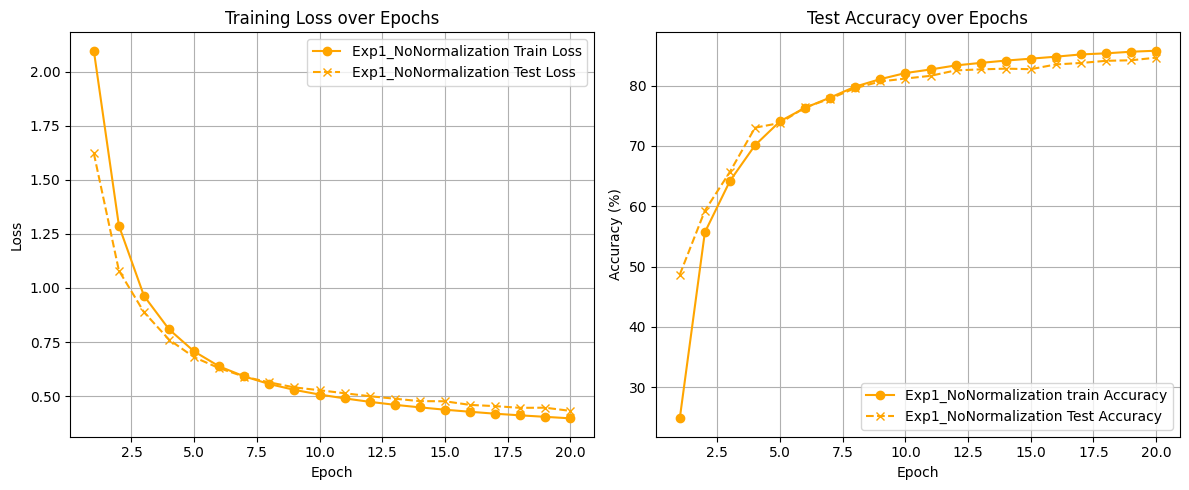

Exp1 final test accuracy: 84.63
Exp1 best test accuracy: 84.63


In [23]:
visualize(exp1, "Exp1_NoNormalization", 20)

print("Exp1 final test accuracy:", exp1[3][-1])
print("Exp1 best test accuracy:", max(exp1[3]))

results_summary.append({
    "Experiment": "Exp1_NoNormalization",
    "Final Train Loss": exp1[0][-1],
    "Final Test Loss": exp1[1][-1],
    "Final Train Accuracy": exp1[2][-1],
    "Final Test Accuracy": exp1[3][-1],
    "Best Test Accuracy": max(exp1[3])
})

## Experience 2

In [ ]:
model_exp2 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=70,
    h2_size=0,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp2 = nn.CrossEntropyLoss()
optimizer_exp2 = optim.SGD(model_exp2.parameters(), lr=0.05)

train_loader_exp2, test_loader_exp2 = get_loaders(64, transform)

exp2 = train(
    model=model_exp2,
    epochs=20,
    optimizer=optimizer_exp2,
    criterion=criterion_exp2,
    train_loader=train_loader_exp2,
    test_loader=test_loader_exp2,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 0.8268 | Test Loss: 0.5766 | Train Accuracy: 73.92 | Test Accuracy: 79.94%


In [ ]:
visualize(exp2, "Exp2_OneHiddenLayer", 20)

print("Exp2 final test accuracy:", exp2[3][-1])
print("Exp2 best test accuracy:", max(exp2[3]))

results_summary.append({
    "Experiment": "Exp2_OneHiddenLayer",
    "Final Train Loss": exp2[0][-1],
    "Final Test Loss": exp2[1][-1],
    "Final Train Accuracy": exp2[2][-1],
    "Final Test Accuracy": exp2[3][-1],
    "Best Test Accuracy": max(exp2[3])
})

## Experience 3

### Learning rate = 0.1

In [ ]:
model_exp3 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp3 = nn.CrossEntropyLoss()
optimizer_exp3 = optim.SGD(model_exp3.parameters(), lr=0.1)

train_loader_exp3, test_loader_exp3 = get_loaders(64, transform)

exp3 = train(
    model=model_exp3,
    epochs=20,
    optimizer=optimizer_exp3,
    criterion=criterion_exp3,
    train_loader=train_loader_exp3,
    test_loader=test_loader_exp3,
    device=device
)

In [ ]:
visualize(exp3, "Exp3_LR_0_1", 20)

print("Exp3 final test accuracy:", exp3[3][-1])
print("Exp3 best test accuracy:", max(exp3[3]))

results_summary.append({
    "Experiment": "Exp3_LR_0_1",
    "Final Train Loss": exp3[0][-1],
    "Final Test Loss": exp3[1][-1],
    "Final Train Accuracy": exp3[2][-1],
    "Final Test Accuracy": exp3[3][-1],
    "Best Test Accuracy": max(exp3[3])
})

### learning rate = 0.001

In [ ]:
model_exp4 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp4 = nn.CrossEntropyLoss()
optimizer_exp4 = optim.SGD(model_exp4.parameters(), lr=0.001)

train_loader_exp4, test_loader_exp4 = get_loaders(64, transform)

exp4 = train(
    model=model_exp4,
    epochs=20,
    optimizer=optimizer_exp4,
    criterion=criterion_exp4,
    train_loader=train_loader_exp4,
    test_loader=test_loader_exp4,
    device=device
)

In [ ]:
visualize(exp4, "Exp4_LR_0_001", 20)

print("Exp4 final test accuracy:", exp4[3][-1])
print("Exp4 best test accuracy:", max(exp4[3]))

results_summary.append({
    "Experiment": "Exp4_LR_0_001",
    "Final Train Loss": exp4[0][-1],
    "Final Test Loss": exp4[1][-1],
    "Final Train Accuracy": exp4[2][-1],
    "Final Test Accuracy": exp4[3][-1],
    "Best Test Accuracy": max(exp4[3])
})

## Experience 5

### Hinge loss

In [ ]:
model_exp5 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp5 = hinge_loss_simple
optimizer_exp5 = optim.SGD(model_exp5.parameters(), lr=0.05)

train_loader_exp5, test_loader_exp5 = get_loaders(64, transform)

exp5 = train(
    model=model_exp5,
    epochs=20,
    optimizer=optimizer_exp5,
    criterion=criterion_exp5,
    train_loader=train_loader_exp5,
    test_loader=test_loader_exp5,
    device=device
)

In [ ]:
visualize(exp5, "Exp5_HingeLoss", 20)

print("Exp5 final test accuracy:", exp5[3][-1])
print("Exp5 best test accuracy:", max(exp5[3]))

results_summary.append({
    "Experiment": "Exp5_HingeLoss",
    "Final Train Loss": exp5[0][-1],
    "Final Test Loss": exp5[1][-1],
    "Final Train Accuracy": exp5[2][-1],
    "Final Test Accuracy": exp5[3][-1],
    "Best Test Accuracy": max(exp5[3])
})

### MSE loss

In [ ]:
model_exp6 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp6 = mse_los
optimizer_exp6 = optim.SGD(model_exp6.parameters(), lr=0.05)

train_loader_exp6, test_loader_exp6 = get_loaders(64, transform)

exp6 = train(
    model=model_exp6,
    epochs=20,
    optimizer=optimizer_exp6,
    criterion=criterion_exp6,
    train_loader=train_loader_exp6,
    test_loader=test_loader_exp6,
    device=device
)

In [ ]:
visualize(exp6, "Exp6_MSELoss", 20)

print("Exp6 final test accuracy:", exp6[3][-1])
print("Exp6 best test accuracy:", max(exp6[3]))

results_summary.append({
    "Experiment": "Exp6_MSELoss",
    "Final Train Loss": exp6[0][-1],
    "Final Test Loss": exp6[1][-1],
    "Final Train Accuracy": exp6[2][-1],
    "Final Test Accuracy": exp6[3][-1],
    "Best Test Accuracy": max(exp6[3])
})

## Experience 5

### h1 = 48, h2 = 300

In [ ]:
model_exp7 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=48,
    h2_size=300,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp7 = nn.CrossEntropyLoss()
optimizer_exp7 = optim.SGD(model_exp7.parameters(), lr=0.05)

train_loader_exp7, test_loader_exp7 = get_loaders(64, transform)

exp7 = train(
    model=model_exp7,
    epochs=20,
    optimizer=optimizer_exp7,
    criterion=criterion_exp7,
    train_loader=train_loader_exp7,
    test_loader=test_loader_exp7,
    device=device
)

In [ ]:
visualize(exp7, "Exp7_H1_48_H2_300", 20)

print("Exp7 final test accuracy:", exp7[3][-1])
print("Exp7 best test accuracy:", max(exp7[3]))

results_summary.append({
    "Experiment": "Exp7_H1_48_H2_300",
    "Final Train Loss": exp7[0][-1],
    "Final Test Loss": exp7[1][-1],
    "Final Train Accuracy": exp7[2][-1],
    "Final Test Accuracy": exp7[3][-1],
    "Best Test Accuracy": max(exp7[3])
})

### h1 = 300, h2 = 48

In [ ]:
model_exp8 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=300,
    h2_size=48,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp8 = nn.CrossEntropyLoss()
optimizer_exp8 = optim.SGD(model_exp8.parameters(), lr=0.05)

train_loader_exp8, test_loader_exp8 = get_loaders(64, transform)

exp8 = train(
    model=model_exp8,
    epochs=20,
    optimizer=optimizer_exp8,
    criterion=criterion_exp8,
    train_loader=train_loader_exp8,
    test_loader=test_loader_exp8,
    device=device
)

In [ ]:
visualize(exp8, "Exp8_H1_300_H2_48", 20)

print("Exp8 final test accuracy:", exp8[3][-1])
print("Exp8 best test accuracy:", max(exp8[3]))

results_summary.append({
    "Experiment": "Exp8_H1_300_H2_48",
    "Final Train Loss": exp8[0][-1],
    "Final Test Loss": exp8[1][-1],
    "Final Train Accuracy": exp8[2][-1],
    "Final Test Accuracy": exp8[3][-1],
    "Best Test Accuracy": max(exp8[3])
})

## Experience 6

In [ ]:
model_exp9 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp9 = nn.CrossEntropyLoss()
optimizer_exp9 = optim.SGD(model_exp9.parameters(), lr=0.05)

train_loader_exp9, test_loader_exp9 = get_loaders(8, transform)

exp9 = train(
    model=model_exp9,
    epochs=20,
    optimizer=optimizer_exp9,
    criterion=criterion_exp9,
    train_loader=train_loader_exp9,
    test_loader=test_loader_exp9,
    device=device
)

In [ ]:
visualize(exp9, "Exp9_BatchSize_8", 20)

print("Exp9 final test accuracy:", exp9[3][-1])
print("Exp9 best test accuracy:", max(exp9[3]))

results_summary.append({
    "Experiment": "Exp9_BatchSize_8",
    "Final Train Loss": exp9[0][-1],
    "Final Test Loss": exp9[1][-1],
    "Final Train Accuracy": exp9[2][-1],
    "Final Test Accuracy": exp9[3][-1],
    "Best Test Accuracy": max(exp9[3])
})

## End

In [ ]:
import pandas as pd

summary_df = pd.DataFrame(results_summary)
summary_df

In [ ]:
summary_df.sort_values(by="Best Test Accuracy", ascending=False)

In [ ]:
print("Baseline vs Exp1_NoNormalization")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp1 best test accuracy:", max(exp1[3]))
print()

print("Baseline vs Exp2_OneHiddenLayer")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp2 best test accuracy:", max(exp2[3]))
print()

print("Baseline vs Exp3_LR_0_1")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp3 best test accuracy:", max(exp3[3]))
print()

print("Baseline vs Exp4_LR_0_001")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp4 best test accuracy:", max(exp4[3]))
print()

print("Baseline vs Exp5_HingeLoss")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp5 best test accuracy:", max(exp5[3]))
print()

print("Baseline vs Exp6_MSELoss")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp6 best test accuracy:", max(exp6[3]))
print()

print("Baseline vs Exp7_H1_48_H2_300")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp7 best test accuracy:", max(exp7[3]))
print()

print("Baseline vs Exp8_H1_300_H2_48")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp8 best test accuracy:", max(exp8[3]))
print()

print("Baseline vs Exp9_BatchSize_8")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp9 best test accuracy:", max(exp9[3]))